In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

### **El Experimento: ¿Qué pasa si aplicamos Softmax de forma iterativa?**

La hipótesis plantea que si Softmax enfoca y amplifica los valores altos reduciendo los bajos, aplicar Softmax repetidamente en un bucle (*reciclando las salidas como nuevas entradas*) debería hacer que el valor máximo sobresalga todavía más.

Sin embargo, al ejecutar este experimento iterativo ocurre un fenómeno intuitivamente contraintuitivo pero matemáticamente inevitable: **la distribución NO se vuelve más aguda, sino que se aplanea y tiende hacia la uniformidad.**

---

### **1. ¿Por qué Softmax iterativo APLANEA la distribución?**

Cuando aplicamos Softmax a un vector de *logits* $\mathbf{z}$:

1. **Primera pasada ($\text{Softmax}(\mathbf{z})$):**
Los *logits* originales (que podían valer $-5, 2, 15$) se transforman en **probabilidades estrictamente acotadas en el rango $(0, 1)$** que suman $1.0$.
2. **Segunda pasada ($\text{Softmax}(\text{Softmax}(\mathbf{z}))$):**
Ahora las entradas para el segundo Softmax ya no son *logits* de amplia escala, sino **valores muy pequeños y cercanos entre sí** (por ejemplo, $[0.001, 0.05, 0.949]$).
3. **La brecha de entrada se destruye:**
Como la diferencia absoluta entre el mayor valor ($0.949$) y el menor ($0.001$) es de apenas $\sim 0.948$ (frente a la diferencia original de $15 - (-5) = 20$), la función exponencial $e^{z_i}$ ya no puede generar contrastes gigantescos.

Al repetir el proceso $N$ veces, las diferencias relativas en cada paso se comprimen tanto que la distribución termina convergiendo a un **estado uniforme** donde todos los tokens tienen exactamente la misma probabilidad ($1/K$).

---

### **2. ¿Qué es realmente el "Soft Softmax"?**

Existe una confusión común en el término:

* **Hard Softmax (o Softmax "agudo"):** Ocurre con **Temperaturas bajas ($T \to 0$)**. Amplifica drásticamente el valor máximo, aplastando los demás a cero (se comporta casi como un *Argmax*).
* **Soft Softmax (o Softmax "suave"):** Ocurre con **Temperaturas altas ($T > 1$)**. Suaviza las diferencias entre *logits*, haciendo la curva más plana y permitiendo que más tokens compartan probabilidad.

Por lo tanto, la respuesta a la pregunta es: **No, un *Soft Softmax* (o la iteración repetida de Softmax) NO hace que el valor más grande resalte más; al contrario, atenúa su dominancia y reparte la probabilidad.**

---

In [12]:
# vamos a ignorar el parametro de temperatura

Nota importante: En los modelos de lenguaje (LLMs) reales, la función Softmax no se aplica de manera iterativa; se ejecuta una sola vez sobre los logits para predecir cada token.

El propósito de este experimento es entender la importancia del rango y la escala numérica de los datos de entrada, y cómo esto condiciona el comportamiento de Softmax. Cuando los logits tienen un rango amplio, Softmax genera una distribución aguda que destaca al ganador. En cambio, cuando el rango numérico se comprime (como ocurre al alimentar las salidas de un Softmax previo), la función pierde su capacidad de amplificar diferencias, aplanando la distribución y demostrando por qué la escala de los logits es crítica durante la generación.

In [13]:
#datos
x = np.linspace(0,1,20)

In [14]:
# calculando un softmax
U = np.exp(x) / np.sum(np.exp(x))

In [15]:
num_repeats = 8 # iteraciones
Ustd = np.zeros(num_repeats)

In [16]:
# Colores para los puntos
colors = plt.cm.turbo(np.linspace(0.1, 0.9, num_repeats))

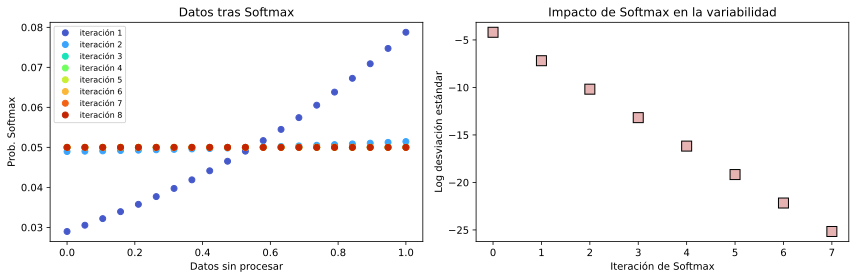

In [17]:
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import numpy as np
import torch

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Graficar
_, axs = plt.subplots(1, 2, figsize=(12, 4))
for r in range(num_repeats):

  # Graficar la distribución de probabilidad
  axs[0].plot(
      x,
      U,
      'o',
      color=colors[r],
      markerfacecolor=colors[r],
      label=f'iteración {r+1}',
  )

  # Calculamos la desviación estándar
  Ustd[r] = np.log(np.std(U))

  # Recalcular softmax
  U = np.exp(U) / np.sum(np.exp(U))


# Graficar la varianza
axs[1].plot(
    range(num_repeats), Ustd, 'ks', markerfacecolor=[0.9, 0.7, 0.7], markersize=10
)
axs[1].set(
    xlabel='Iteración de Softmax',
    ylabel='Log desviación estándar',
    title='Impacto de Softmax en la variabilidad',
)

axs[0].legend(fontsize=8)
axs[0].set(
    xlabel='Datos sin procesar',
    ylabel='Prob. Softmax',
    title='Datos tras Softmax',
)

plt.tight_layout()
plt.show()

### **Análisis del Experimento: Colapso Iterativo de Softmax**

Este gráfico ilustra el **efecto de compresión y pérdida de variabilidad** cuando aplicamos la función Softmax de forma iterativa sobre un conjunto de $N = 20$ datos contenidos entre $0$ y $1$.

---

### **1. Gráfica Izquierda: `Softmaxed data` (Convergencia a $0.05$)**

* **Primera iteración (Puntos azules):**
Los datos de entrada brutos (*Raw data*) están acotados en el rango $[0, 1]$. Al aplicar Softmax por primera vez, la salida genera una curva suave y ascendente (prácticamente lineal dentro de este rango tan estrecho).
* **Segunda iteración en adelante (Puntos celestes a rojos):**
A partir del paso 2, todos los puntos colapsan drásticamente sobre una **línea recta horizontal en $y = 0.05$**.
* **¿De dónde sale exactamente el valor $0.05$?**
Proviene directamente del primer axioma de las distribuciones de probabilidad: **la suma total debe ser $1.0$** ($\sum P(x_i) = 1$).
Dado que el experimento utiliza $N = 20$ elementos y la transformación iterativa destruye las diferencias entre ellos haciendo que todos se vuelvan equivalentes, la masa de probabilidad se reparte de forma perfectamente equitativa:

$$\text{Probabilidad Uniforme} = \frac{1}{N} = \frac{1}{20} = 0.05 \quad (5\% \text{ para cada elemento})$$

---

### **2. Gráfica Derecha: `Impact of softmaxing on variability` (Caída de la Varianza)**

* **Uso de la Escala Logarítmica:**
La gráfica derecha mide la **desviación estándar** de los valores en cada iteración. Se aplica la transformación logarítmica ($\log(\text{std})$) porque la dispersión numérica cae a una velocidad tan extrema que, en escala lineal regular, parecería desplomarse a cero inmediatamente desde la iteración 2.
* **Caída Exponencial Constante:**
La relación lineal descendente en la escala logarítmica (pasando de $-4$ hasta $-25$) demuestra que **la variabilidad se reduce de forma exponencial** en cada iteración. En la iteración 7, la variabilidad es prácticamente cero a nivel de precisión de punto flotante ($e^{-25} \approx 1.38 \times 10^{-11}$).

---


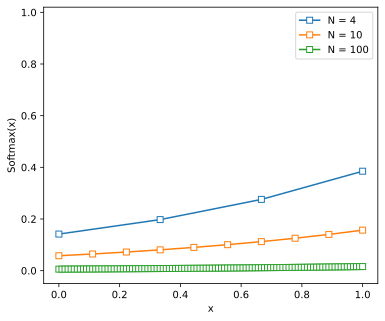

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Por qué aplicar softmax repetidamente suprime la variabilidad

# Tamaños de muestra
N = [4, 10, 100]

# Graficar
plt.figure(figsize=(6, 5))

for n in N:
  # Los datos (ej. logits de tokens entre 0 y 1)
  x = np.linspace(0, 1, n)

  # Aplicar softmax a los datos
  smx = np.exp(x) / np.sum(np.exp(x))

  # Graficar con marcadores cuadrados, relleno blanco y etiquetas personalizadas
  plt.plot(x, smx, "s-", markerfacecolor="w", label=f"N = {n}")

# Formato para coincidir con el gráfico de referencia
plt.legend()
plt.xlabel("x")
plt.ylabel("Softmax(x)")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.02)

plt.show()

### **El Efecto de la Cantidad de Elementos ($N$) en Softmax**

Este experimento demuestra cómo el tamaño del vocabulario ($N$) condiciona la magnitud de las probabilidades individuales tras aplicar Softmax, manteniendo el mismo rango de *logits* iniciales ($[0, 1]$).

---

### **1. ¿Por qué el tamaño de la muestra ($N$) diluye las probabilidades?**

La razón fundamental radica en la **condición de normalización**:

$$\sum_{i=1}^{N} \text{Softmax}(x_i) = 1.0$$

* **Para $N = 4$:** Si repartes una masa total de probabilidad de $1.0$ entre $4$ elementos, la probabilidad promedio se sitúa cerca de $1/4 = 0.25$ ($25\%$). Las diferencias entre los valores brutos todavía generan cambios visibles en la pendiente.
* **Para $N = 10$:** La probabilidad promedio cae a $1/10 = 0.10$ ($10\%$). La curva comienza a aplastarse.
* **Para $N = 100$:** La probabilidad promedio se reduce a $1/100 = 0.01$ ($1\%$). La línea se percibe prácticamente plana sobre el eje $y = 0$.

---

### **2. Conexión directa con los LLMs (Vocabularios de $+100.000$ tokens)**

Cuando un tokenizador (como el de GPT-4) evalúa un vocabulario de $N \approx 100.000$ *tokens*:

* La probabilidad promedio esperada si todos los *logits* fueran idénticos sería de apenas $1 / 100.000 = 10^{-5}$ ($0.00001$).
* Esto explica por qué en los LLMs la función Softmax **suprime agresivamente la inmensa mayoría de las opciones**, enviando a casi $99.99\%$ del vocabulario a probabilidades ínfimas pegadas al cero.
* También pone en evidencia la necesidad técnica de usar **LogSoftmax** durante el entrenamiento para evitar que estos valores infinitesimales desaparezcan por *underflow* numérico.

---


## Ejercicio 2 utilizando un rango mas amplio para el softmax

In [19]:
# Exploraremos el impacto de la temperatura

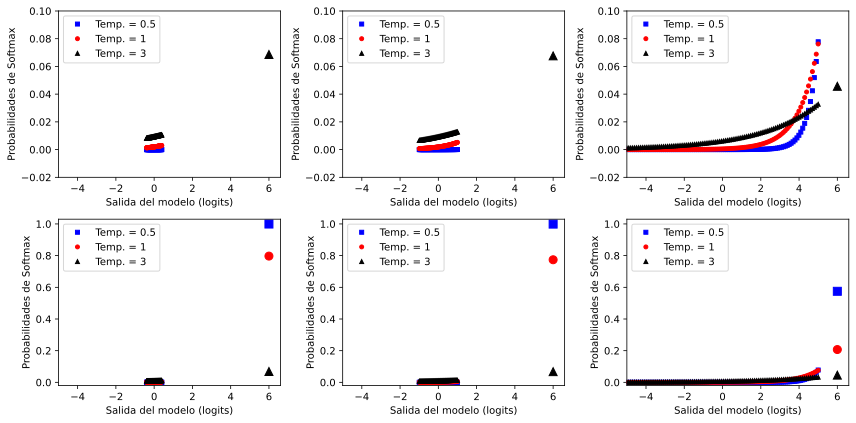

In [23]:
temps = [0.5, 1, 3]
bounds = [0.4, 1, 5]

colors = 'brk'
shapes = 'so^'

_, axs = plt.subplots(2, 3, figsize=(12, 6))

for bndi in range(3):

  # Crear logits (ej. salidas del modelo)
  logits = torch.linspace(-bounds[bndi], bounds[bndi], 100)
  # Agregar un logit adicional distinto, potencialmente un valor atípico (outlier)
  logits = torch.cat((logits, torch.tensor([6])))

  for ti in range(3):

    # Calcular softmax con esta temperatura
    T = temps[ti]
    sm = torch.softmax(logits / T, dim=0)

    # Graficar los mismos datos dos veces (escalando después)
    for ii in range(2):
      # Graficar todos los elementos excepto el último
      axs[ii, bndi].plot(
          logits[:-1],
          sm[:-1],
          linestyle='none',
          markerfacecolor=colors[ti],
          marker=shapes[ti],
          markeredgecolor=colors[ti],
          markersize=4,
          label=f'Temp. = {T}',
      )
      # Dibujar el último elemento por separado con un marcador más grande
      axs[ii, bndi].plot(
          logits[-1],
          sm[-1],
          linestyle='none',
          markerfacecolor=colors[ti],
          marker=shapes[ti],
          markeredgecolor=colors[ti],
          markersize=8,
      )


# Configuración de ejes para los gráficos superiores para resaltar el impacto en valores más pequeños
for a in axs[0, :]:
  a.set(
      xlim=[-bounds[-1], 6.6],
      ylim=[-0.02, 0.1],
      xlabel='Salida del modelo (logits)',
      ylabel='Probabilidades de Softmax',
  )  # Límite en Y con zoom
  a.legend(loc='upper left')

# Configuración de ejes para los gráficos inferiores para mostrar probabilidades hasta 1
for a in axs[1, :]:
  a.set(
      xlim=[-bounds[-1], 6.6],
      ylim=[-0.02, 1.03],
      xlabel='Salida del modelo (logits)',
      ylabel='Probabilidades de Softmax',
  )
  a.legend(loc='upper left')


plt.tight_layout()
plt.show()

### **Análisis de la Matriz de Gráficas: Escalas de Temperatura y Outliers (*Outlier Logits*)**

Esta matriz de 6 subgráficas (2 filas $\times$ 3 columnas) ilustra el impacto combinado de dos variables clave sobre Softmax: **la escala del eje Y (probabilidad total)** y la presencia de un **valor atípico prominente (*outlier logit*)**.

---

### **1. Filas: La Escala del Eje Y (*Softmax probabilities*)**

* **Fila Superior ($y \in [-0.02, 0.10]$):**
Muestra un acercamiento de alta resolución (*zoom*) sobre el rango $[0, 0.10]$. Nos permite observar con precisión qué ocurre con los tokens de probabilidad baja y media que normalmente se ven pegados al suelo en una gráfica completa.
* **Fila Inferior ($y \in [-0.02, 1.00]$):**
Muestra la escala real completa de probabilidades de $0.0$ a $1.0$. Aquí se aprecia con claridad la dominancia del token con el *logit* máximo ($z = 6$).

---

### **2. Columnas: La Distribución de los *Logits* de Entrada**

* **Columnas 1 y 2 (Izquierda y Centro - Distribución Dispar):**
Tienen un grupo denso de *logits* agrupados cerca de $0$ (entre $-1$ y $1$) y un **único *outlier* distante en $z = 6$**.
* **Efecto de la Temperatura:**
* **$T = 0.5$ (Cuadrados Azules - Baja Temperatura):** El *outlier* ($z=6$) absorbe prácticamente el **$100\%$ ($1.0$) de la probabilidad**. Todo el grupo alrededor de $0$ queda aplastado en $0.00$.
* **$T = 1.0$ (Círculos Rojos - Estándar):** El *outlier* retiene cerca del **$80\%$ ($0.80$)**, mientras que el resto apenas recibe probabilidades insignificantes.
* **$T = 3.0$ (Triángulos Negros - Alta Temperatura):** El *outlier* cae drásticamente a menos del **$10\%$ ($0.07$)** de probabilidad. Al aplanar la curva, la masa de probabilidad se reparte entre los múltiples tokens concentrados alrededor de $0$.




* **Columna 3 (Derecha - Distribución Continua):**
Muestra una secuencia continua de *logits* que va desde $-5$ hasta $6$.
* Al haber una transición suave de valores hacia la derecha, la curva exponencial se dibuja claramente en la fila superior.
* En la fila inferior se observa cómo **$T = 0.5$ (Azul)** genera una pendiente extremadamente inclinada hacia el valor final ($\approx 0.60$), mientras que **$T = 3.0$ (Negro)** suaviza la trayectoria repartiendo el riesgo entre todos los valores mayores a $2$.



---

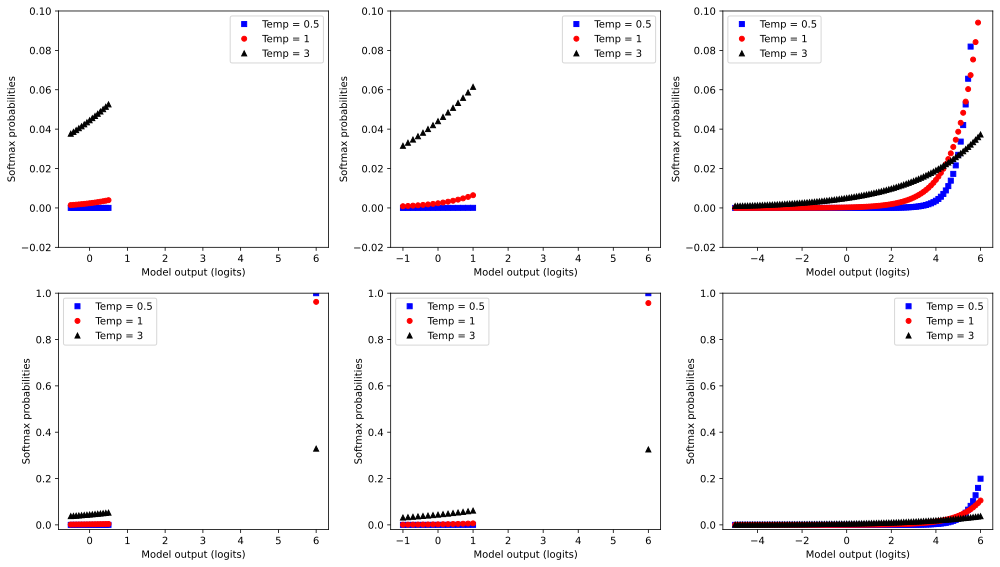

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definición de Softmax con escala de Temperatura
def softmax(x, T):
    # Se dividen los logits entre la temperatura T antes de la exponencial
    exp_x = np.exp(x / T)
    return exp_x / np.sum(exp_x)

# 2. Generación de los 3 conjuntos de logits (Columnas)
# Columna 1: Logits muy juntos cerca de 0 y un outlier alto en 6
x1 = np.concatenate([np.linspace(-0.5, 0.5, 15), [6.0]])

# Columna 2: Rango un poco más amplio cerca de 0 y el mismo outlier en 6
x2 = np.concatenate([np.linspace(-1.0, 1.0, 15), [6.0]])

# Columna 3: Distribución continua de logits desde -5 hasta 6
x3 = np.linspace(-5.0, 6.0, 100)

datasets = [x1, x2, x3]

# 3. Configuración de estilos y temperaturas
temperatures = [0.5, 1.0, 3.0]
styles = [
    ('bs', 'Temp = 0.5'),  # Blue square
    ('ro', 'Temp = 1'),    # Red circle
    ('k^', 'Temp = 3')     # Black triangle
]

# 4. Construcción de la matriz de gráficos (2 filas x 3 columnas)
fig, axs = plt.subplots(2, 3, figsize=(14, 8))

for col_idx, x in enumerate(datasets):
    for (marker, label), T in zip(styles, temperatures):
        # Calculamos la probabilidad softmax ajustada por temperatura
        probs = softmax(x, T)

        # Graficar en la Fila 0 (Zoom)
        axs[0, col_idx].plot(x, probs, marker, label=label, markersize=5)

        # Graficar en la Fila 1 (Escala Completa)
        axs[1, col_idx].plot(x, probs, marker, label=label, markersize=5)

    # --- Configuración Fila Superior (ZOOM en el suelo) ---
    axs[0, col_idx].set_ylim(-0.02, 0.10)  # Recorta el eje Y de 0 a 0.10
    axs[0, col_idx].set_xlabel('Model output (logits)')
    axs[0, col_idx].set_ylabel('Softmax probabilities')
    axs[0, col_idx].legend()

    # --- Configuración Fila Inferior (Escala Completa 0 a 1) ---
    axs[1, col_idx].set_ylim(-0.02, 1.00)  # Muestra el eje Y completo de 0 a 1
    axs[1, col_idx].set_xlabel('Model output (logits)')
    axs[1, col_idx].set_ylabel('Softmax probabilities')
    axs[1, col_idx].legend()

plt.tight_layout()
plt.show()

Los logits son los puntajes brutos que calcula el modelo; la Temperatura es la perilla de escalado que decide qué tan drástica o suave será la competencia entre esos mismos puntajes al convertirlos en probabilidades.

